# LLM-from-scratch-stack: End-to-End Mini GPT Tutorial

This notebook walks through building a **small but real language model training pipeline** from raw data to instruction tuning.

You will:

1. Download a real dataset (WikiText-103)
2. Convert it into the JSONL format expected by the training stack
3. Train a Byte-Pair Encoding (BPE) tokenizer
4. Pretrain a small GPT model
5. Perform supervised fine-tuning (SFT) on instruction-style examples
6. Evaluate perplexity and run simple behavioral probes
7. Interactively generate text

This is not a frontier-scale model. It is a **clean, educational reference implementation** of the full LLM lifecycle.

---

## Why This Notebook Exists

Modern LLM workflows can feel opaque. Libraries hide the moving parts.

This tutorial intentionally exposes the core components:

* Tokenization
* Autoregressive training
* Loss masking
* Checkpointing
* Fine-tuning
* Sampling

The goal is clarity over scale.

---

## Architecture Overview

At a high level, the system looks like this:

```
Raw Text → JSONL → Tokenizer → GPT Pretraining → Instruction SFT → Generation
```

Each stage is implemented using the same modular training stack from the repository.

---

## What "From Scratch" Means Here

You are not using a pretrained HuggingFace model.

You are:

* Training your own tokenizer
* Initializing a GPT model from random weights
* Pretraining it on real text
* Fine-tuning it with structured instruction prompts
* Running inference manually with temperature + top-p sampling

That is the complete lifecycle of a modern LLM.

---

## Expected Behavior

After pretraining + SFT, the model should:

* Produce short coherent completions
* Answer small arithmetic prompts it saw during SFT
* Respond politely to greeting-style prompts
* Produce simple descriptive sentences

It will not:

* Be factually strong
* Perform complex reasoning
* Generalize far beyond its tiny dataset

This is a demonstration model, not a production system.

---

## Runtime Expectations

On GPU:

* Pretraining should take minutes depending on `max_steps`.
* SFT should complete quickly.

On CPU:

* Reduce step counts significantly.

---

## Recommended Usage

1. Restart kernel.
2. Run all cells.
3. Inspect the tokenizer artifact.
4. Watch the pretraining progress bar.
5. Observe loss curves.
6. Interact with the final model.

---

## What You Should Learn

By the end of this notebook, you should understand:

* How tokenization shapes model behavior
* Why autoregressive models predict next-token distributions
* How masking enables instruction tuning
* How sampling parameters affect output diversity
* Why data composition matters for behavior

---

Let’s get started!


In [1]:
# --- 0) Bootstrap: paths, imports, torch.load compat (PyTorch 2.6+) ---
from __future__ import annotations
import re
import json, os, random, sys
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from types import SimpleNamespace

import time
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for _ in range(12):
        if (cur / "src" / "llmstack").exists() and (cur / "pyproject.toml").exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    # fallback: current working dir
    return Path.cwd().resolve()

REPO_ROOT = find_repo_root(Path.cwd())
#print("REPO_ROOT:", REPO_ROOT)

# ensure imports work
for p in [REPO_ROOT, REPO_ROOT/"src"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))


In [2]:
# --- 1) Repo imports ---
from llmstack.data.datamodule import DataModule
from llmstack.eval.perplexity import evaluate_perplexity
from llmstack.eval.probes import run_probes
from llmstack.model.gpt import GPTModel
from llmstack.optim.adamw import build_adamw
from llmstack.optim.schedulers import build_scheduler
from llmstack.train.engine import Trainer
from llmstack.utils.logging import RunLogger
from llmstack.utils.seed import seed_everything
from llmstack.tokenization.tokenizer import Tokenizer  # repo wrapper (loads tokenizer.json from a directory)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEED = 1337
seed_everything(SEED)



print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PRECISION = "bf16" if (DEVICE == "cuda" and torch.cuda.is_bf16_supported()) else ("fp16" if DEVICE == "cuda" else "fp32")
print("DEVICE:", DEVICE, "| PRECISION:", PRECISION)

from contextlib import nullcontext

if PRECISION == "bf16":
    AMP_CONTEXT = torch.autocast(device_type="cuda", dtype=torch.bfloat16)
elif PRECISION == "fp16":
    AMP_CONTEXT = torch.autocast(device_type="cuda", dtype=torch.float16)
else:
    AMP_CONTEXT = nullcontext()

DATA_DIR = REPO_ROOT / "data" / "toy"
ARTIFACTS_DIR = REPO_ROOT / "artifacts"
RUNS_DIR = REPO_ROOT / "runs"
for d in [DATA_DIR, ARTIFACTS_DIR, RUNS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def load_ckpt(path: Path, device):
    # PyTorch 2.6+ defaults weights_only=True; our checkpoints include more than raw tensors.
    return torch.load(path, map_location=device, weights_only=False)

2026-02-21 16:42:36.726374: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-21 16:42:36.735517: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771710156.745856  114536 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771710156.748968  114536 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-21 16:42:36.760814: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
DEVICE: cuda | PRECISION: bf16


## 2) Download Dataset and Prepare Training Files

We now move from concept to data.

A language model learns by predicting the next token over massive text corpora. For this MVP, we use **WikiText-103**, a cleaned Wikipedia dataset commonly used in language modeling research.

We will:

1. Download the dataset using HuggingFace Datasets.
2. Extract the raw text field.
3. Convert it into JSONL format expected by the repo’s `DataModule`.

Why JSONL?

The training stack reads one example per line in the form:

```json
{"text": "some training string"}
```

This simple structure keeps the data loader modular and scalable.

We write two files:

* `data/toy/train.jsonl` → used for pretraining
* `data/toy/val.jsonl` → used for validation/perplexity evaluation

Each line is a single training example.

This step bridges external datasets and your internal training engine.

After this cell runs, you will have a clean, local corpus ready for tokenizer training and GPT pretraining.



In [ ]:
'''
SEED = 1337
seed_everything(SEED, deterministic=False)

from datasets import load_dataset
from tqdm.auto import tqdm
import json

train_path = DATA_DIR / "train.jsonl"
val_path   = DATA_DIR / "val.jsonl"

# -------------------------------------------------
# Load C4 (streaming) and shuffle training stream
# -------------------------------------------------
ds = load_dataset("allenai/c4", "en", streaming=True)

train_stream = ds["train"].shuffle(seed=SEED, buffer_size=50_000)
val_stream   = ds["validation"]  # keep deterministic

# -------------------------------------------------
# JSONL writer
# -------------------------------------------------
def write_jsonl(split, out_path: Path, max_lines: int, desc: str):
    n = 0
    with out_path.open("w", encoding="utf-8") as f:
        pbar = tqdm(total=max_lines, desc=desc)
        for item in split:
            text = (item.get("text") or "").strip()
            if not text:
                continue

            f.write(json.dumps({"text": text}, ensure_ascii=False) + "\n")
            n += 1
            pbar.update(1)

            if n % 10_000 == 0:
                f.flush()

            if n >= max_lines:
                break

        pbar.close()
    return n

# -------------------------------------------------
# Size controls
# -------------------------------------------------
MAX_TRAIN_LINES = 200_000
MAX_VAL_LINES   = 10_000

n_tr = write_jsonl(train_stream, train_path, MAX_TRAIN_LINES, desc="write train")
n_va = write_jsonl(val_stream,   val_path,   MAX_VAL_LINES,   desc="write val")

print(f"Wrote train lines: {n_tr}")
print(f"Wrote val lines:   {n_va}")

'''

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

write train:   0%|          | 0/200000 [00:00<?, ?it/s]

In [ ]:
item = next(iter(train_stream))
print("Got first example length:", len(item["text"]))

In [3]:

SEED = 1337
seed_everything(SEED, deterministic=False)

from datasets import load_dataset
from tqdm.auto import tqdm
import json

train_path = DATA_DIR / "train.jsonl"
val_path   = DATA_DIR / "val.jsonl"

# -------------------------------------------------
# Load OpenWebText (non-streaming, cached locally)
# -------------------------------------------------
ds = load_dataset("openwebtext")

# Create 99% / 1% train/val split
split = ds["train"].train_test_split(
    test_size=0.01,
    seed=SEED,
    shuffle=True,
)

train_split = split["train"]
val_split   = split["test"]

print("Train size:", len(train_split))
print("Val size:",   len(val_split))


# -------------------------------------------------
# JSONL writer
# -------------------------------------------------
def write_jsonl(split, out_path: Path, max_lines: int, desc: str):
    n = 0
    with out_path.open("w", encoding="utf-8") as f:
        pbar = tqdm(total=min(max_lines, len(split)), desc=desc)

        for item in split:
            text = (item.get("text") or "").strip()
            if not text:
                continue

            f.write(json.dumps({"text": text}, ensure_ascii=False) + "\n")
            n += 1
            pbar.update(1)

            if n % 10_000 == 0:
                f.flush()

            if n >= max_lines:
                break

        pbar.close()

    return n


# -------------------------------------------------
# Size controls (you do NOT need millions here)
# -------------------------------------------------
MAX_TRAIN_LINES = 2_000_000
MAX_VAL_LINES   = 50_000

n_tr = write_jsonl(train_split, train_path, MAX_TRAIN_LINES, desc="write train")
n_va = write_jsonl(val_split,   val_path,   MAX_VAL_LINES,   desc="write val")

print(f"Wrote train lines: {n_tr}")
print(f"Wrote val lines:   {n_va}")


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/80 [00:00<?, ?it/s]

Train size: 7933631
Val size: 80138


write train:   0%|          | 0/2000000 [00:00<?, ?it/s]

write val:   0%|          | 0/50000 [00:00<?, ?it/s]

Wrote train lines: 2000000
Wrote val lines:   50000


## 3) Train the Tokenizer (Creating `tokenizer.json`)

Before a model can learn language, it must learn how to break text into tokens.

A tokenizer defines the vocabulary and determines how raw strings are converted into integer IDs. Those IDs are what the GPT model actually sees.

In this stack, the `Tokenizer` wrapper expects a directory containing a trained tokenizer artifact:

```
artifacts/tokenizer/tokenizer.json
```

The tokenizer must include special tokens:

* `<pad>` → padding token
* `<bos>` → beginning-of-sequence token
* `<eos>` → end-of-sequence token
* `<unk>` → unknown token

We train a **byte-level BPE (Byte Pair Encoding)** tokenizer.

Why byte-level BPE?

* It avoids out-of-vocabulary issues.
* It works directly at the byte level.
* It handles arbitrary Unicode text robustly.
* It is widely used in modern LLMs.

Training the tokenizer consists of:

1. Scanning the training corpus.
2. Learning frequent byte merges.
3. Constructing a vocabulary of subword units.
4. Saving the resulting merge rules + vocab into `tokenizer.json`.

This file becomes a permanent artifact of the model.

Important: The model architecture depends on the tokenizer vocabulary size. Once trained, the tokenizer must remain fixed for the rest of pretraining and SFT.

After this step, you will have:

* A concrete vocabulary size.
* A consistent mapping from text → token IDs.
* A reusable artifact that makes the training stack deterministic and reproducible.

With the tokenizer in place, we are ready to initialize the GPT model.


In [4]:
# --- Train a BPE tokenizer and save as artifacts/tokenizer/tokenizer.json ---

import os, json, time
os.environ["TOKENIZERS_PARALLELISM"] = "false"

try:
    from tokenizers import Tokenizer as HFTokenizer
    from tokenizers.models import BPE
    from tokenizers.pre_tokenizers import ByteLevel
    from tokenizers.trainers import BpeTrainer
    from tokenizers.normalizers import NFKC
    from tokenizers.decoders import ByteLevel as ByteLevelDecoder
except ImportError:
    %pip -q install tokenizers
    from tokenizers import Tokenizer as HFTokenizer
    from tokenizers.models import BPE
    from tokenizers.pre_tokenizers import ByteLevel
    from tokenizers.trainers import BpeTrainer
    from tokenizers.normalizers import NFKC
    from tokenizers.decoders import ByteLevel as ByteLevelDecoder

TOKENIZER_DIR = ARTIFACTS_DIR / "tokenizer"
TOKENIZER_DIR.mkdir(parents=True, exist_ok=True)
TOKENIZER_JSON = TOKENIZER_DIR / "tokenizer.json"

corpus_txt = ARTIFACTS_DIR / "tokenizer_corpus.txt"

def build_corpus_txt(jsonl_path: Path, out_txt: Path, text_field="text", max_lines: int = 50_000):
    n = 0
    with jsonl_path.open("r", encoding="utf-8") as f_in, out_txt.open("w", encoding="utf-8") as f_out:
        for line in f_in:
            obj = json.loads(line)
            t = (obj.get(text_field) or "").strip()
            if not t:
                continue
            f_out.write(t.replace("\r\n", "\n") + "\n")
            n += 1
            if n >= max_lines:
                break
    return n


# -------------------------------------------------
# Skip retraining if tokenizer already exists
# -------------------------------------------------
if TOKENIZER_JSON.exists():
    print("Tokenizer already exists. Loading:", TOKENIZER_JSON)
else:
    n = build_corpus_txt(train_path, corpus_txt, max_lines=100_000)
    print("Tokenizer corpus lines:", n)

    mb = os.path.getsize(corpus_txt) / (1024**2)
    print(f"corpus_txt size: {mb:.1f} MB")

    VOCAB_SIZE = 16_384
    SPECIAL_TOKENS = ["<pad>", "<bos>", "<eos>", "<unk>"]

    tok = HFTokenizer(BPE(unk_token="<unk>"))
    tok.normalizer = NFKC()
    tok.pre_tokenizer = ByteLevel(add_prefix_space=True)
    tok.decoder = ByteLevelDecoder()

    trainer = BpeTrainer(
        vocab_size=VOCAB_SIZE,
        special_tokens=SPECIAL_TOKENS,
        min_frequency=2,
        limit_alphabet=1000,
        show_progress=True,
    )

    t0 = time.time()
    tok.train([str(corpus_txt)], trainer)
    print(f"tokenizer train seconds: {time.time()-t0:.1f}")

    # --- Safety checks on HF tokenizer BEFORE wrapping ---
    vocab = tok.get_vocab()
    for s in SPECIAL_TOKENS:
        assert s in vocab, f"Missing special token in vocab: {s}"
    assert len(vocab) <= VOCAB_SIZE + len(SPECIAL_TOKENS)

    tok.save(str(TOKENIZER_JSON))
    print("Tokenizer saved:", TOKENIZER_JSON)


# -------------------------------------------------
# Load via repo wrapper
# -------------------------------------------------
tokenizer = Tokenizer(TOKENIZER_DIR)

print("Tokenizer vocab_size:", tokenizer.vocab_size)

Tokenizer already exists. Loading: /home/jarettpoliner/Downloads/llm-from-scratch-stack-main/artifacts/tokenizer/tokenizer.json
Tokenizer vocab_size: 16384


## 4) Configure a Small GPT (Model + Training Settings)

Now we define the model itself.

A GPT model is controlled by two main groups of parameters:

1. **Architecture hyperparameters** (depth, width, sequence length)
2. **Training hyperparameters** (learning rate, batch size, number of steps)

For this notebook, we deliberately choose values that are:

* Small enough to run quickly on a single GPU
* Large enough to demonstrate meaningful learning
* Stable enough to train without extensive tuning

### Model Configuration

You are instantiating a compact decoder-only Transformer with:

* A fixed maximum sequence length
* A modest embedding dimension
* A small number of attention heads
* A small stack of transformer blocks

This keeps parameter count low while preserving the core mechanics of autoregressive language modeling.

### Training Knobs You Can Turn

Two parameters matter most for output quality:

* `PRETRAIN_STEPS` → how long the model sees raw text
* `MAX_TRAIN_LINES` → how much of the dataset you feed it

Increasing either improves quality — at the cost of runtime.

For a true MVP demonstration:

* A few thousand pretraining steps are enough to show structure.
* Tens of thousands begin producing noticeably better coherence.

### Mental Model

More data × more steps = better next-token prediction.

But this notebook prioritizes speed and clarity over scale.

Once configuration is set, we are ready to pretrain the model from random initialization.


In [5]:
import math
from datetime import datetime
from types import SimpleNamespace
import torch

def auto_batch_settings(seq_len: int):
    """
    Pick micro-batch and grad-accum to keep tokens/update in a sane range across VRAM sizes.
    Goal: stable optimization, not maximal throughput.
    """
    if DEVICE != "cuda":
        return 4, 1

    try:
        props = torch.cuda.get_device_properties(0)
        gb = props.total_memory / (1024**3)
    except Exception:
        gb = 16.0

    # Conservative micro-batches by VRAM.
    if gb <= 10:
        micro = 1 if seq_len >= 512 else 2
    elif gb <= 16:
        micro = 2 if seq_len >= 512 else 4
    elif gb <= 24:
        micro = 4 if seq_len >= 512 else 6
    else:
        micro = 6 if seq_len >= 512 else 8

    # Target tokens per optimizer step (global batch * seq_len)
    # For this model, ~64k-192k tokens/update is a good stability band.
    target_tokens = 96_000
    accum = max(1, int(round(target_tokens / (micro * seq_len))))

    # Clamp accum so it doesn't get silly.
    accum = min(accum, 16)
    return micro, accum


# -----------------------------
# Training knobs
# -----------------------------
SEQ_LEN = 512                      # if VRAM tight: 256
PRETRAIN_STEPS = 50_000            # better quality comes mostly from more + better data
SFT_STEPS = 3000                  # 1k-3k typical for this toy SFT
RUN_DPO = False

# ---- Manual override for stable training ----

if DEVICE == "cuda":
    MICRO_BATCH = 2      # reduce if OOM
    GRAD_ACCUM = 16      # 4 × 16 × 512 = 32768 tokens/step
else:
    MICRO_BATCH = 4
    GRAD_ACCUM = 1

GLOBAL_BATCH = MICRO_BATCH * GRAD_ACCUM
TOKENS_PER_STEP = GLOBAL_BATCH * SEQ_LEN

print("TOKENS_PER_STEP:", TOKENS_PER_STEP)

print(f"Auto batch: micro={MICRO_BATCH} accum={GRAD_ACCUM} global={GLOBAL_BATCH} tokens/step={TOKENS_PER_STEP:,}")

# SFT batch is separate (your SFT loop does its own padding + single forward pass)
SFT_BATCH = 16 if DEVICE == "cuda" else 8


RUN_NAME = datetime.now().strftime("mvp_%Y%m%d_%H%M%S")
RUN_DIR = RUNS_DIR / RUN_NAME
CKPT_DIR = RUN_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Warmup as a fraction of steps (more robust than hardcoding 1000)
WARMUP_STEPS = max(1000, int(0.1 * PRETRAIN_STEPS))  # ~5%
BASE_LR = 2e-5
MIN_LR = 0.2 * BASE_LR

cfg = SimpleNamespace(
    model=SimpleNamespace(
        vocab_size=tokenizer.vocab_size,
        n_layers=8,
        n_heads=8,
        d_model=512,
        d_ff=2048,
        max_seq_len=SEQ_LEN,
        dropout=0.1,
        norm_type="rmsnorm",
        rope_enabled=True,
        tie_embeddings=True,
        gradient_checkpointing=False,  # turn on only if OOM
    ),
    data=SimpleNamespace(
        train_path=str(train_path),
        val_path=str(val_path),
        format="jsonl",
        text_field="text",
        seq_len=SEQ_LEN,
        pack_sequences=False,
        num_workers=0 if DEVICE == "cuda" else 0,
        shuffle=True,
        streaming=False,
        add_bos=True,
        add_eos=True,
        pad_to_seq_len=True,
    ),
    train=SimpleNamespace(
        seed=SEED,
        device=DEVICE,
        precision=PRECISION,
        compile=False,                 # flip True after everything is correct
        grad_clip=1.0,
        grad_accum_steps=GRAD_ACCUM,
        micro_batch_size=MICRO_BATCH,
        max_steps=PRETRAIN_STEPS,

        # Better cadence defaults
        eval_interval=max(500, PRETRAIN_STEPS // 10),
        log_interval=max(20,  PRETRAIN_STEPS // 100),
        save_interval=max(1000, PRETRAIN_STEPS // 3),

        out_dir=str(RUNS_DIR),
        run_name=RUN_NAME,
        resume_path=None,
        max_eval_batches=50,
        deterministic=False,
    ),
    optim=SimpleNamespace(
        name="adamw",
        lr=BASE_LR,
        betas=(0.9, 0.95),
        weight_decay=0.03,             # 0.1 is often too strong at this scale
        eps=1e-8,
    ),
    sched=SimpleNamespace(
        name="warmup_cosine",
        warmup_steps=WARMUP_STEPS,
        min_lr=MIN_LR,
    ),
    log=SimpleNamespace(use_wandb=False, wandb_project="llmstack", jsonl=True, tensorboard=True),
    run_dir=str(CKPT_DIR),
)

#print("RUN_DIR:", RUN_DIR)

TOKENS_PER_STEP: 16384
Auto batch: micro=2 accum=16 global=32 tokens/step=16,384


In [6]:
print("Vocab size:", tokenizer.vocab_size)
print("Train file exists:", Path(train_path).exists())
print("Val file exists:", Path(val_path).exists())
print("Tokens/step:", TOKENS_PER_STEP)

Vocab size: 16384
Train file exists: True
Val file exists: True
Tokens/step: 16384


## 5) Pretraining

We now train the GPT model from random initialization.

Pretraining teaches the model to predict the **next token** given all previous tokens. This is autoregressive language modeling:

```
P(x_t | x_1, ..., x_{t-1})
```

For example:

```
The ocean is vast and → deep / blue / mysterious
```

The model learns this pattern across every token in the dataset.

---

### What Happens Each Step

1. Sample a batch of token sequences.
2. Run them through the Transformer.
3. Compute cross-entropy next-token loss.
4. Backpropagate.
5. Update weights.

This repeats for `PRETRAIN_STEPS` iterations.

---

### What Pretraining Gives You

* Grammar and syntax
* Basic word associations
* Statistical structure of language

It does not yet teach instruction following. That happens during SFT.

---

### What to Monitor

* Training loss should decrease.
* Validation perplexity should improve.

After pretraining, you have a GPT checkpoint that models raw language patterns.

Next: instruction fine-tuning.



In [ ]:
torch.set_float32_matmul_precision("high")
torch.cuda.empty_cache()

dm = DataModule(cfg, tokenizer, world_size=1, rank=0)

model = GPTModel(cfg.model).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params/1e6:.2f}M")

optimizer = build_adamw(model, cfg.optim)
scheduler = build_scheduler(optimizer, cfg.sched, cfg.train.max_steps)

logger = RunLogger(str(RUN_DIR), jsonl=cfg.log.jsonl, tensorboard=cfg.log.tensorboard)

trainer = Trainer(
    cfg,
    model,
    optimizer,
    scheduler,
    logger,
    dm.train_dataloader(),
    dm.val_dataloader(),
    device=DEVICE
)

trainer.fit()
trainer.save_checkpoint("pretrain_last.pt")
logger.close()

PRETRAIN_CKPT = CKPT_DIR / "pretrain_last.pt"
assert PRETRAIN_CKPT.exists(), PRETRAIN_CKPT
print("Saved pretrain checkpoint:", PRETRAIN_CKPT)

Model parameters: 33.86M


In [ ]:
# ---- NOW plot pretraining learning curve ----
import json
import matplotlib.pyplot as plt
from pathlib import Path

metrics_file = Path(RUN_DIR) / "metrics.jsonl"

def iter_json_objects_from_text(text: str):
    """
    Robustly parse 0..N JSON objects from a string, even if concatenated.
    """
    dec = json.JSONDecoder()
    s = text.strip()
    i = 0
    n = len(s)
    while i < n:
        while i < n and s[i].isspace():
            i += 1
        if i >= n:
            break
        obj, j = dec.raw_decode(s, i)
        yield obj
        i = j

# Read whole file at once (safe: metrics is small)
raw = metrics_file.read_text(encoding="utf-8")

# If the file contains literal "\n" sequences instead of real newlines, normalize
raw = raw.replace("\\n", "\n")

steps = []
losses = []
lrs = []

for line in raw.splitlines():
    line = line.strip()
    if not line:
        continue
    for obj in iter_json_objects_from_text(line):
        if "step" in obj and "loss" in obj:
            steps.append(int(obj["step"]))
            losses.append(float(obj["loss"]))
            if "lr" in obj:
                lrs.append((int(obj["step"]), float(obj["lr"])))

plt.figure(figsize=(8,4))
plt.plot(steps, losses, label="Loss")
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Pretraining Loss Curve")
plt.grid(True)
plt.legend()
plt.show()

if lrs:
    s_lr, v_lr = zip(*lrs)
    plt.figure(figsize=(8,4))
    plt.plot(s_lr, v_lr, label="LR")
    plt.yscale("log")
    plt.xlabel("Step")
    plt.ylabel("Learning Rate")
    plt.title("LR Schedule")
    plt.grid(True)
    plt.legend()
    plt.show()

In [29]:
from pathlib import Path
metrics_file = Path(RUN_DIR) / "metrics.jsonl"
with metrics_file.open("r") as f:
    line = f.readline()
print(line[:300])

{"step": 80, "loss": 9.43732762336731, "lr": 2.43e-06, "grad_norm": 2.003653049468994, "tokens_per_sec": 3792.4824729628763}\n{"step": 160, "loss": 8.922738432884216, "lr": 4.83e-06, "grad_norm": 1.5676017999649048, "tokens_per_sec": 3871.8441348653364}\n{"step": 240, "loss": 8.594004034996033, "lr"


## 6) Evaluation Utilities

Before moving to fine-tuning, we evaluate the pretrained model.

Evaluation answers a simple question: **Is the model learning meaningful structure?**

We use two lightweight metrics:

### 1) Perplexity

Perplexity measures how well the model predicts the next token on held-out validation data.

Lower perplexity = better next-token prediction.

It is the standard metric for autoregressive language modeling.

---

### 2) Simple Behavioral Probes

We also run small prompt-based probes to observe qualitative behavior.

These are not formal benchmarks. They provide intuition about:

* Coherence
* Repetition
* Basic pattern learning

---

Evaluation serves two purposes:

* Verify that training is working
* Establish a baseline before instruction fine-tuning

Next, we shift from modeling raw language to modeling structured instruction-response behavior.



In [23]:
@torch.no_grad()
def run_eval(ckpt_path: Path, label: str) -> dict:
    torch.cuda.empty_cache()

    eval_model = GPTModel(cfg.model).to(DEVICE)

    ckpt = load_ckpt(ckpt_path, DEVICE)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    eval_model.load_state_dict(state)
    eval_model.eval()

    with AMP_CONTEXT:
        ppl = evaluate_perplexity(
            eval_model,
            dm.val_dataloader(),
            DEVICE,
            max_batches=cfg.train.max_eval_batches,
        )

        probes = run_probes(eval_model, tokenizer, DEVICE)

    report = {
        "label": label,
        "checkpoint": str(ckpt_path),
        "perplexity": ppl,
        "probes": probes,
    }

    out = RUN_DIR / f"eval_{label}.json"
    out.write_text(json.dumps(report, indent=2), encoding="utf-8")
    print(json.dumps(report, indent=2))
    return report


pretrain_report = run_eval(PRETRAIN_CKPT, "pretrain")

{
  "label": "pretrain",
  "checkpoint": "/home/jarettpoliner/Downloads/llm-from-scratch-stack-main/runs/mvp_20260221_113940/checkpoints/pretrain_last.pt",
  "perplexity": {
    "loss": 5.44771066180701,
    "ppl": 232.22591323437038,
    "tokens": 56318
  },
  "probes": {
    "repeat_after_me": -26.068010330200195,
    "bracket_matching": 1.0,
    "simple_addition": -8.372848510742188
  }
}


## 7) Supervised Fine-Tuning (SFT)

Pretraining teaches the model general language structure. SFT teaches it **how to respond**.

Here we fine-tune using instruction–response pairs.

### Key Implementation Details

To remain consistent with pretraining:

* Prepend `<bos>`
* Append `<eos>`
* Mask loss over the prompt region

Only the response tokens contribute to the loss. The model learns:

```
Prompt → Desired Response
```

---

### Why Mask the Prompt?

During SFT, we do not want the model to relearn the prompt. We want it to learn how to *continue* the prompt correctly.

Masking ensures gradients flow only through response tokens.

---

### Why Longer Responses?

Using structured responses like:

```
The answer is 9.
```

provides stronger supervision than single-token outputs.

This stabilizes learning and improves instruction-style behavior.

After SFT, the model should follow basic prompts rather than merely continue raw text.


arith_examples: 53093
instr_examples: 50004


/tmp/ipykernel_16571/58885903.py:346: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(PRECISION == "fp16"))


SFT Training:   0%|                                    | 0/3000 [00:00<?, ?it/s]


SFT completed in 241.30 seconds
Saved SFT checkpoint: /home/jarettpoliner/Downloads/llm-from-scratch-stack-main/runs/mvp_20260221_113940/checkpoints/sft_last.pt


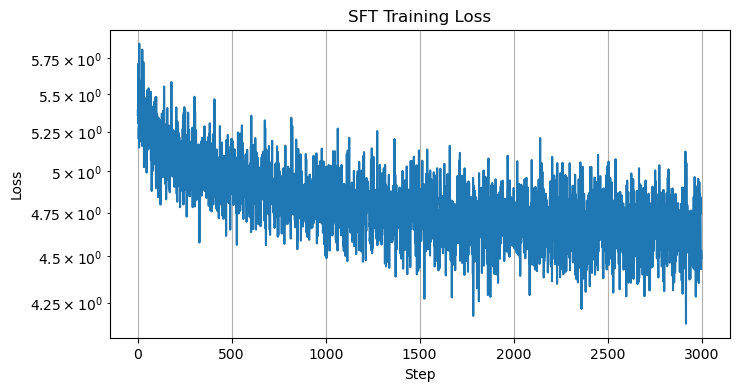

In [24]:
# DROP-IN SFT BLOCK (peak/robust):
# - response-only loss (prompt masked)
# - BOS/EOS, PAD-safe batching, ctx-safe truncation
# - arithmetic mix (small, sufficient)
# - real SFT dataset from HF (UltraChat default, Dolly fallback)
# - AMP enabled (bf16/fp16), optional layer-freeze
# - cosine LR w/ warmup for SFT
#
# REQUIREMENT: pip install datasets
# ASSUMES: SEED, DEVICE, cfg (cfg.model.max_seq_len), tokenizer (repo Tokenizer),
#          GPTModel, load_ckpt, PRETRAIN_CKPT, CKPT_DIR, RUN_DIR, SFT_STEPS,
#          AMP_CONTEXT (from your bootstrap cell) are already defined.

import re
import math
import random
import time
import json
import numpy as np
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# -----------------------------
# Special id helpers
# -----------------------------
def get_pad_id(tok):
    # repo Tokenizer has pad_id; keep fallbacks for safety
    for attr in ("pad_id", "pad_token_id"):
        if hasattr(tok, attr):
            pid = getattr(tok, attr)
            if pid is not None:
                return int(pid)
    if hasattr(tok, "special_to_id") and isinstance(tok.special_to_id, dict):
        if "<pad>" in tok.special_to_id:
            return int(tok.special_to_id["<pad>"])
    if hasattr(tok, "token_to_id"):
        pid = tok.token_to_id("<pad>")
        if pid is not None:
            return int(pid)
    if hasattr(tok, "eos_id"):
        return int(tok.eos_id)
    return 0

# -----------------------------
# Canonical prompt formatting + normalization
# -----------------------------
pat_shorthand = re.compile(r"^\s*(\d+)\s*([+\-*/])\s*(\d+)\s*\??\s*$")

def qfmt(q: str) -> str:
    return f"Q: {q.strip()}\n### Response:\n"

def ensure_sft_prompt(p: str) -> str:
    s = (p or "").strip()
    if "### Response:" in s:
        return s if s.endswith("\n") else s + "\n"
    m = pat_shorthand.fullmatch(s)
    if m:
        a, op, b = m.group(1), m.group(2), m.group(3)
        return qfmt(f"What is {a} {op} {b}?")
    return qfmt(s)

def clean_text(s: str) -> str:
    s = (s or "").replace("\r\n", "\n").replace("\r", "\n")
    s = re.sub(r"[ \t]+", " ", s)
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()

def dedup_examples(ex_list):
    seen = set()
    out = []
    for ex in ex_list:
        p = clean_text(ex["prompt"])
        r = clean_text(ex["response"])
        key = (p, r)
        if key not in seen:
            out.append({"prompt": p if p.endswith("\n") else p + "\n", "response": r})
            seen.add(key)
    return out

# -----------------------------
# Arithmetic prompt augmentation (light + safe)
# -----------------------------
_arith_q_re = re.compile(
    r"Q:\s*What\s+is\s+(\d+)\s*([+\-*/])\s*(\d+)\?\s*\n###\s*Response:\s*\n",
    re.IGNORECASE,
)

def randomize_op_spacing(prompt: str, rng: random.Random) -> str:
    m = _arith_q_re.search(prompt)
    if not m:
        return prompt
    a, op, b = m.group(1), m.group(2), m.group(3)
    # keep * and / stable (tokenization sensitive)
    if op in ("*", "/"):
        return prompt
    left  = " " if rng.random() < 0.5 else ""
    right = " " if rng.random() < 0.5 else ""
    new = f"Q: What is {a}{left}{op}{right}{b}?\n### Response:\n"
    return _arith_q_re.sub(new, prompt, count=1)

# -------------------------------------------------
# Robust response-only SFT step with safe truncation
# -------------------------------------------------
def sft_step_bos_eos(
    model,
    tokenizer,
    batch,
    device: str,
    rng: random.Random | None = None,
):
    pad_id = get_pad_id(tokenizer)
    bos_id = int(tokenizer.bos_id)
    eos_id = int(tokenizer.eos_id)

    ids_list = []
    labels_list = []
    max_ctx = int(cfg.model.max_seq_len)

    for ex in batch:
        prompt = ensure_sft_prompt(ex["prompt"])
        resp   = clean_text(ex["response"])

        if rng is not None:
            prompt = randomize_op_spacing(prompt, rng)

        full = prompt + resp

        ids_full = [bos_id] + tokenizer.encode(full) + [eos_id]
        ids_cut  = [bos_id] + tokenizer.encode(prompt)  # cut point includes prompt only
        cut = len(ids_cut)

        # Truncate from the LEFT but always keep BOS at position 0
        if len(ids_full) > max_ctx:
            overflow = len(ids_full) - max_ctx
            ids_full = [bos_id] + ids_full[1 + overflow:]
            cut = max(1, cut - overflow)

        lab = ids_full.copy()
        lab[:cut] = [-100] * cut  # response-only loss

        ids_list.append(ids_full)
        labels_list.append(lab)

    B = len(ids_list)
    max_len = max(len(x) for x in ids_list)

    x = torch.full((B, max_len), pad_id, dtype=torch.long, device=device)
    y = torch.full((B, max_len), -100, dtype=torch.long, device=device)

    for i, (ids, lab) in enumerate(zip(ids_list, labels_list)):
        L = len(ids)
        x[i, :L] = torch.tensor(ids, dtype=torch.long, device=device)
        y[i, :L] = torch.tensor(lab, dtype=torch.long, device=device)

    # Loss mask: count only non-ignored labels; never count padding
    loss_mask = ((y != -100) & (x != pad_id)).to(torch.float32)

    _, loss = model(x, labels=y, loss_mask=loss_mask)
    return loss

# -------------------------------------------------
# Build SFT pools (Arithmetic + Real instruction data)
# -------------------------------------------------
rng = random.Random(SEED)

def add(ex_list, prompt, response):
    ex_list.append({"prompt": prompt, "response": response})

# ---- Arithmetic pool (small but sufficient)
arith_examples = []

ADD_MAX = 60
SUB_MAX = 60
MUL_MAX = 20
DIV_MAX_A = 120
DIV_MAX_B = 20

for a in range(0, ADD_MAX + 1):
    for b in range(0, ADD_MAX + 1):
        add(arith_examples, qfmt(f"What is {a} + {b}?"), f"The answer is {a+b}.")

for a in range(0, SUB_MAX + 1):
    for b in range(0, SUB_MAX + 1):
        add(arith_examples, qfmt(f"What is {a} - {b}?"), f"The answer is {a-b}.")

for a in range(0, MUL_MAX + 1):
    for b in range(0, MUL_MAX + 1):
        add(arith_examples, qfmt(f"What is {a} * {b}?"), f"The answer is {a*b}.")

for b in range(1, DIV_MAX_B + 1):
    for a in range(0, DIV_MAX_A + 1):
        if a % b == 0:
            add(arith_examples, qfmt(f"What is {a} / {b}?"), f"The answer is {a//b}.")
        else:
            add(arith_examples, qfmt(f"What is {a} / {b}?"), f"The answer is {a/b:.2f}.")

syn_templates = [
    "What is {a} plus {b}?",
    "Compute {a} + {b}.",
    "What is the sum of {a} and {b}?",
    "What is {a} minus {b}?",
    "Compute {a} - {b}.",
    "What is the difference between {a} and {b}?",
    "What is {a} times {b}?",
    "Compute {a} * {b}.",
    "What is the product of {a} and {b}?",
    "What is {a} divided by {b}?",
    "Compute {a} / {b}.",
    "What is the quotient of {a} and {b}?",
]

pat_canon = re.compile(r"Q:\s*What\s+is\s+(\d+)\s*([+\-*/])\s*(\d+)\?\n### Response:\n")

arith_aug = []
for ex in arith_examples:
    arith_aug.append(ex)
    m = pat_canon.match(ex["prompt"])
    if not m:
        continue
    a, op, b = m.group(1), m.group(2), m.group(3)

    for raw in (f"{a}{op}{b}", f"{a} {op} {b}", f"{a}{op}{b}?", f"{a} {op} {b}?"):
        arith_aug.append({"prompt": f"{raw}\n### Response:\n", "response": ex["response"]})

    if rng.random() < 0.15:
        tpl = syn_templates[rng.randrange(len(syn_templates))]
        arith_aug.append({"prompt": qfmt(tpl.format(a=a, b=b)), "response": ex["response"]})

arith_examples = dedup_examples(arith_aug)
print("arith_examples:", len(arith_examples))

# ---- Instruction pool (REAL SFT dataset)
instr_examples = []

def build_instr_from_hf(dataset_name: str, split: str, max_items: int, seed: int):
    try:
        from datasets import load_dataset
    except Exception as e:
        raise RuntimeError("Please: pip install datasets") from e

    rng_local = random.Random(seed)
    ds = load_dataset(dataset_name, split=split)

    out = []
    for ex in ds:
        user = None
        assistant = None

        msgs = ex.get("messages", None)
        if isinstance(msgs, list) and len(msgs) >= 2:
            for m in msgs[::-1]:
                if assistant is None and m.get("role") == "assistant":
                    assistant = m.get("content", "")
                elif assistant is not None and m.get("role") == "user":
                    user = m.get("content", "")
                    break

        if user is None and "instruction" in ex and "response" in ex:
            inst = ex.get("instruction", "")
            ctx = ex.get("context", "")
            user = inst if not ctx else (inst.strip() + "\n" + ctx.strip())
            assistant = ex.get("response", "")

        if not user or not assistant:
            continue

        user = clean_text(user)
        assistant = clean_text(assistant)

        # cheap quality filters
        if len(user) < 8 or len(assistant) < 2:
            continue
        if assistant.lower().startswith("as an ai") and len(assistant) < 80:
            continue
        if "### Response:" in assistant:
            continue
        if assistant.count("\n") > 80:
            continue

        out.append({"prompt": qfmt(user), "response": assistant})
        if len(out) >= max_items:
            break

    rng_local.shuffle(out)
    return dedup_examples(out)

DATASET_NAME = "HuggingFaceH4/ultrachat_200k"
DATASET_SPLIT = "train_sft"
MAX_INSTR = 50_000

try:
    instr_examples = build_instr_from_hf(DATASET_NAME, DATASET_SPLIT, MAX_INSTR, SEED)
except Exception:
    DATASET_NAME = "databricks/databricks-dolly-15k"
    DATASET_SPLIT = "train"
    instr_examples = build_instr_from_hf(DATASET_NAME, DATASET_SPLIT, min(MAX_INSTR, 15_000), SEED)

# Small consistent anchors (don’t overdo it)
anchors = [
    ("Who are you?", "I am a small language model trained in this repository."),
    ("What is your name?", "I am a small language model trained in this repository."),
    ("What day is it?", "I do not know the current date in this setup."),
    ("What's the time?", "I do not know the current time in this setup."),
]
for q, a in anchors:
    instr_examples.append({"prompt": qfmt(q), "response": a})

instr_examples = dedup_examples(instr_examples)
print("instr_examples:", len(instr_examples))

# -------------------------------------------------
# Load pretrained model + train SFT
# -------------------------------------------------
sft_model = GPTModel(cfg.model).to(DEVICE)

ckpt = load_ckpt(PRETRAIN_CKPT, DEVICE)
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
sft_model.load_state_dict(state)

sft_model.train()

# Optional: freeze bottom blocks for stability (comment out if you want full finetune)
FREEZE_N_BLOCKS = 0  # set 4 for small models if you see instruction collapse
if FREEZE_N_BLOCKS > 0:
    for blk in sft_model.blocks[:FREEZE_N_BLOCKS]:
        for p in blk.parameters():
            p.requires_grad = False

sft_optim = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, sft_model.parameters()),
    lr=2e-5,
    weight_decay=0.01,
)

# Cosine LR w/ warmup
def lr_lambda(step: int):
    warmup = max(1, int(0.05 * SFT_STEPS))
    if step < warmup:
        return float(step) / warmup
    # cosine from 1 -> 0.1 (avoid collapsing too hard at end)
    prog = (step - warmup) / max(1, (SFT_STEPS - warmup))
    return 0.1 + 0.9 * (0.5 * (1.0 + math.cos(math.pi * prog)))

sft_sched = torch.optim.lr_scheduler.LambdaLR(sft_optim, lr_lambda)
scaler = torch.cuda.amp.GradScaler(enabled=(PRECISION == "fp16"))

# Batch size: keep modest on 8GB
SFT_BATCH = 8 if DEVICE == "cuda" else 8

def arith_frac_at(step: int, total_steps: int) -> float:
    return 0.01 if step < int(0.7 * total_steps) else 0.02

def sample_batch(arith_pool, instr_pool, batch_size, arith_frac, rng):
    n_arith = int(round(batch_size * arith_frac))
    n_instr = batch_size - n_arith
    batch = [arith_pool[rng.randrange(len(arith_pool))] for _ in range(n_arith)]
    batch += [instr_pool[rng.randrange(len(instr_pool))] for _ in range(n_instr)]
    rng.shuffle(batch)
    return batch

loss_history = []
t0 = time.time()
progress = tqdm(range(SFT_STEPS), desc="SFT Training", dynamic_ncols=True)

for step in progress:
    af = arith_frac_at(step, SFT_STEPS)
    batch = sample_batch(arith_examples, instr_examples, SFT_BATCH, af, rng)

    with AMP_CONTEXT:
        loss = sft_step_bos_eos(
            sft_model,
            tokenizer,
            batch,
            device=DEVICE,
            rng=rng,
        )

    sft_optim.zero_grad(set_to_none=True)
    sft_optim.zero_grad(set_to_none=True)
    
    if scaler.is_enabled():
        scaler.scale(loss).backward()
        scaler.unscale_(sft_optim)
        torch.nn.utils.clip_grad_norm_(sft_model.parameters(), 1.0)
        scaler.step(sft_optim)
        scaler.update()
    else:
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sft_model.parameters(), 1.0)
        sft_optim.step()
        
    sft_sched.step()

    lv = float(loss.item())
    loss_history.append(lv)
    lr_now = float(sft_sched.get_last_lr()[0])
    progress.set_postfix(loss=f"{lv:.4f}", arith_frac=f"{af:.2f}", lr=f"{lr_now:.2e}")

print(f"\nSFT completed in {(time.time()-t0):.2f} seconds")

SFT_CKPT = CKPT_DIR / "sft_last.pt"
torch.save({"model": sft_model.state_dict(), "step": SFT_STEPS}, SFT_CKPT)
print("Saved SFT checkpoint:", SFT_CKPT)

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.yscale("log")
plt.title("SFT Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [25]:
sft_report = run_eval(SFT_CKPT, "sft")

{
  "label": "sft",
  "checkpoint": "/home/jarettpoliner/Downloads/llm-from-scratch-stack-main/runs/mvp_20260221_113940/checkpoints/sft_last.pt",
  "perplexity": {
    "loss": 5.6723585841694595,
    "ppl": 290.71941260711253,
    "tokens": 56318
  },
  "probes": {
    "repeat_after_me": -25.73228645324707,
    "bracket_matching": 1.0,
    "simple_addition": -7.555148601531982
  }
}


## 8) Text Generation

With pretraining and SFT complete, we can generate text.

Generation works by repeatedly:

1. Feeding the current token sequence into the model.
2. Extracting the final-step logits.
3. Sampling the next token.
4. Appending it to the sequence.

This continues until `<eos>` is produced or `max_new_tokens` is reached.

---

### Key Implementation Details

Several small details matter for correct behavior:

* `GPTModel` returns `(logits, loss)` → use only the logits.
* Use `tokenizer.eos_id` to stop generation.
* Decode only newly generated tokens (not the prompt).
* Crop the input context to `max_seq_len` to prevent overflow.

---

### Sampling Controls

Generation quality depends heavily on sampling:

* **Temperature** → controls randomness.
* **Top-p (nucleus sampling)** → restricts sampling to the most probable mass.
* **Repetition penalty** → discourages loops.

These do not change the model’s knowledge. They only change how we sample from its distribution.

After this step, you can interact with your trained mini-LLM and observe its learned behavior.



In [27]:
import re
import torch
import torch.nn.functional as F


# -------------------------------------------------
# Prompt normalization (SFT format only)
# -------------------------------------------------

def normalize_user_prompt(user_input: str) -> str:
    s = user_input.strip()

    if "### Response:" in s:
        return s if s.endswith("\n") else s + "\n"

    # normalize multiply/divide glyphs
    s = s.replace("×", "*").replace("÷", "/")
    s = re.sub(r"(\d+)\s*[xX]\s*(\d+)", r"\1 * \2", s)

    # raw arithmetic like "2+7" -> canonical training format
    m = re.fullmatch(r"(\d+)\s*([+\-*/])\s*(\d+)", s)
    if m:
        a, op, b = m.group(1), m.group(2), m.group(3)
        return f"Q: What is {a} {op} {b}?\n### Response:\n"

    if not s.endswith("?") and re.match(r"(?i)^(who|what|when|where|why|how)\b", s):
        s = s + "?"

    return f"Q: {s}\n### Response:\n"


# -------------------------------------------------
# Top-p (nucleus) sampling
# -------------------------------------------------

def sample_top_p(probs: torch.Tensor, p: float) -> torch.Tensor:
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cumulative = torch.cumsum(sorted_probs, dim=-1)

    cutoff = cumulative > p
    cutoff[..., 0] = False

    sorted_probs = sorted_probs.masked_fill(cutoff, 0.0)
    sorted_probs = sorted_probs / sorted_probs.sum().clamp(min=1e-8)

    next_token = torch.multinomial(sorted_probs, 1)
    return sorted_idx[next_token]


# -------------------------------------------------
# Research-grade generation
# -------------------------------------------------
def _ban_repeat_ngrams(next_logits: torch.Tensor, input_ids: torch.Tensor, no_repeat_ngram_size: int):
    # input_ids: [T]
    if no_repeat_ngram_size <= 0:
        return next_logits
    T = input_ids.numel()
    n = no_repeat_ngram_size
    if T < n:
        return next_logits

    # build a map: (prefix tuple) -> set(next_token)
    prefixes = {}
    ids = input_ids.tolist()
    for i in range(T - n + 1):
        prefix = tuple(ids[i : i + n - 1])
        nxt = ids[i + n - 1]
        prefixes.setdefault(prefix, set()).add(nxt)

    current_prefix = tuple(ids[-(n - 1):]) if n > 1 else tuple()
    banned = prefixes.get(current_prefix, None)
    if not banned:
        return next_logits

    next_logits[list(banned)] = -1e9
    return next_logits


@torch.no_grad()
def generate_text(
    model,
    tokenizer,
    user_text: str,
    max_new_tokens: int = 96,
    temperature: float = 0.3,          # safer default for small/weak models
    top_p: float | None = 0.95,
    repetition_penalty: float = 1.15,
    no_repeat_ngram_size: int = 3,
):
    model.eval()

    prompt = normalize_user_prompt(user_text)
    input_ids = [int(tokenizer.bos_id)] + tokenizer.encode(prompt)
    x = torch.tensor([input_ids], dtype=torch.long, device=DEVICE)

    for _ in range(max_new_tokens):
        # preserve BOS when trimming context
        if x.size(1) > cfg.model.max_seq_len:
            x = torch.cat([x[:, :1], x[:, -(cfg.model.max_seq_len - 1):]], dim=1)

        logits, _ = model(x)
        next_logits = logits[0, -1, :].clone()

        # mask special tokens (except eos)
        for attr in ("bos_id", "pad_id", "unk_id"):
            if hasattr(tokenizer, attr):
                next_logits[int(getattr(tokenizer, attr))] = -1e9

        # repetition penalty (token-level)
        if repetition_penalty and repetition_penalty != 1.0:
            uniq = torch.unique(x[0])
            vals = next_logits[uniq]
            next_logits[uniq] = torch.where(vals > 0, vals / repetition_penalty, vals * repetition_penalty)

        # ngram blocking
        next_logits = _ban_repeat_ngrams(next_logits, x[0], no_repeat_ngram_size)

        if temperature <= 0:
            next_id = torch.argmax(next_logits).view(1, 1)
        else:
            probs = F.softmax(next_logits / max(temperature, 1e-6), dim=-1)
            if top_p is not None:
                next_id = sample_top_p(probs, top_p).view(1, 1)
            else:
                next_id = torch.multinomial(probs, 1).view(1, 1)

        x = torch.cat([x, next_id], dim=1)

        if int(next_id.item()) == int(tokenizer.eos_id):
            break

    gen_ids = x[0].tolist()[len(input_ids):]
    return tokenizer.decode(gen_ids).strip()

# -----------------------------
# quick test
# -----------------------------
infer = GPTModel(cfg.model).to(DEVICE)
infer.load_state_dict(load_ckpt(SFT_CKPT, DEVICE)["model"])
infer.eval()

tests = [
    "Say hello politely.",
    "Write one short sentence about the ocean.",
    "2 + 7",
    "What is 10 + 9?",
]

for t in tests:
    print("You:", t)
    print("LLM:", generate_text(
        infer,
        tokenizer,
        t,
        max_new_tokens=64,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
    ))
    print()

You: Say hello politely.
LLM: Absolutely! Here are some tips for how to look at the same time:

1. The parsma: This is a common element of a type of garden, with the latest special styles that are used in the dish. It is also easy to try and helps to work well with some flavors

You: Write one short sentence about the ocean.
LLM: Certainly! Here are some additional information on the dish:

1. Use a hole for the home to the side of the stone:
2. Encitutional gapr's pomles, which is used to the vegetables and pepper. This is a great way to be used to create an essential

You: 2 + 7
LLM: Yes, there are several other options in the process of the base of the design:

1. B., C. The T. D. S.
2.
4. The region of the C.A. A.C.
3. Adister the P.5.
5.

You: What is 10 + 9?
LLM: Sure, I can be happy to get a few examples of how the hotel is in the city. Here are some examples:

1. You can use the island's local culture:
2. "3.5. The 2018" is a popular home-based located in the world. The world i

In [28]:
tests = ["2+7", "10+9", "9-4", "8*8", "Say hello politely.", "Write one short sentence about the ocean."]
for t in tests:
    print("You:", t)
    print("LLM:", generate_text(infer, tokenizer, t, max_new_tokens=48))
    print()

You: 2+7
LLM: Yes, there are several examples of how the C12 is in the first time of the year. The list is made from the number of steps to the next day and the week, which is not only a few examples of the

You: 10+9
LLM: Sure, here are some examples of how to use the `b`. Here are a few examples:

1. Use a "post" or "n'" to "dap" by "By"

You: 9-4
LLM: Yes, the first two of the year was a few examples of the most popular years. The last year, the day was a great way to be more than the years, and it was a significant role in the world. The time

You: 8*8
LLM: Yes, the most popular features of the latest features in the world is a great way to ensure that it's important for its own. The best thing is to be used to make it more efficient and easy to use. Here are some

You: Say hello politely.
LLM: Yes, there are many other types of ingredients that can be used in the world. Here are some examples:

1. Use a variety of options:
1) This is a great way to make it more unique and easy

Yo

## 8) Talk to it youself!

In [14]:
print("LLM ready. Type 'exit' to quit.")
while True:
    user = input("\nYou: ").strip()
    if user.lower() in {"exit", "quit"}:
        break
    print("\nLLM:", generate_text(infer, tokenizer, user, max_new_tokens=96, temperature=0.3, top_p=0.9))

LLM ready. Type 'exit' to quit.



You:  Write one sentence about the ocean.



LLM: Sure, here's a few more examples of the ocean's ocean's ocean's ocean's water-saving water-saving water-saving water-saving water-saving water-saving water-saving water-saving water-saving water-saving water-saving water-saving water-saving water-saving water-saving water-saving water-saving water-saving water-saving water



You:  exit


In [19]:
print("TOKENS_PER_STEP:", TOKENS_PER_STEP)
print("Total tokens seen:", TOKENS_PER_STEP * PRETRAIN_STEPS)

TOKENS_PER_STEP: 8192
Total tokens seen: 409600000
